In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import math

Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [25]:
df = pd.read_csv('creditcard.csv')

In [26]:
df.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [27]:
df.isnull().sum().max()

np.int64(0)

In [28]:
df.duplicated().sum()

np.int64(1081)

In [29]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

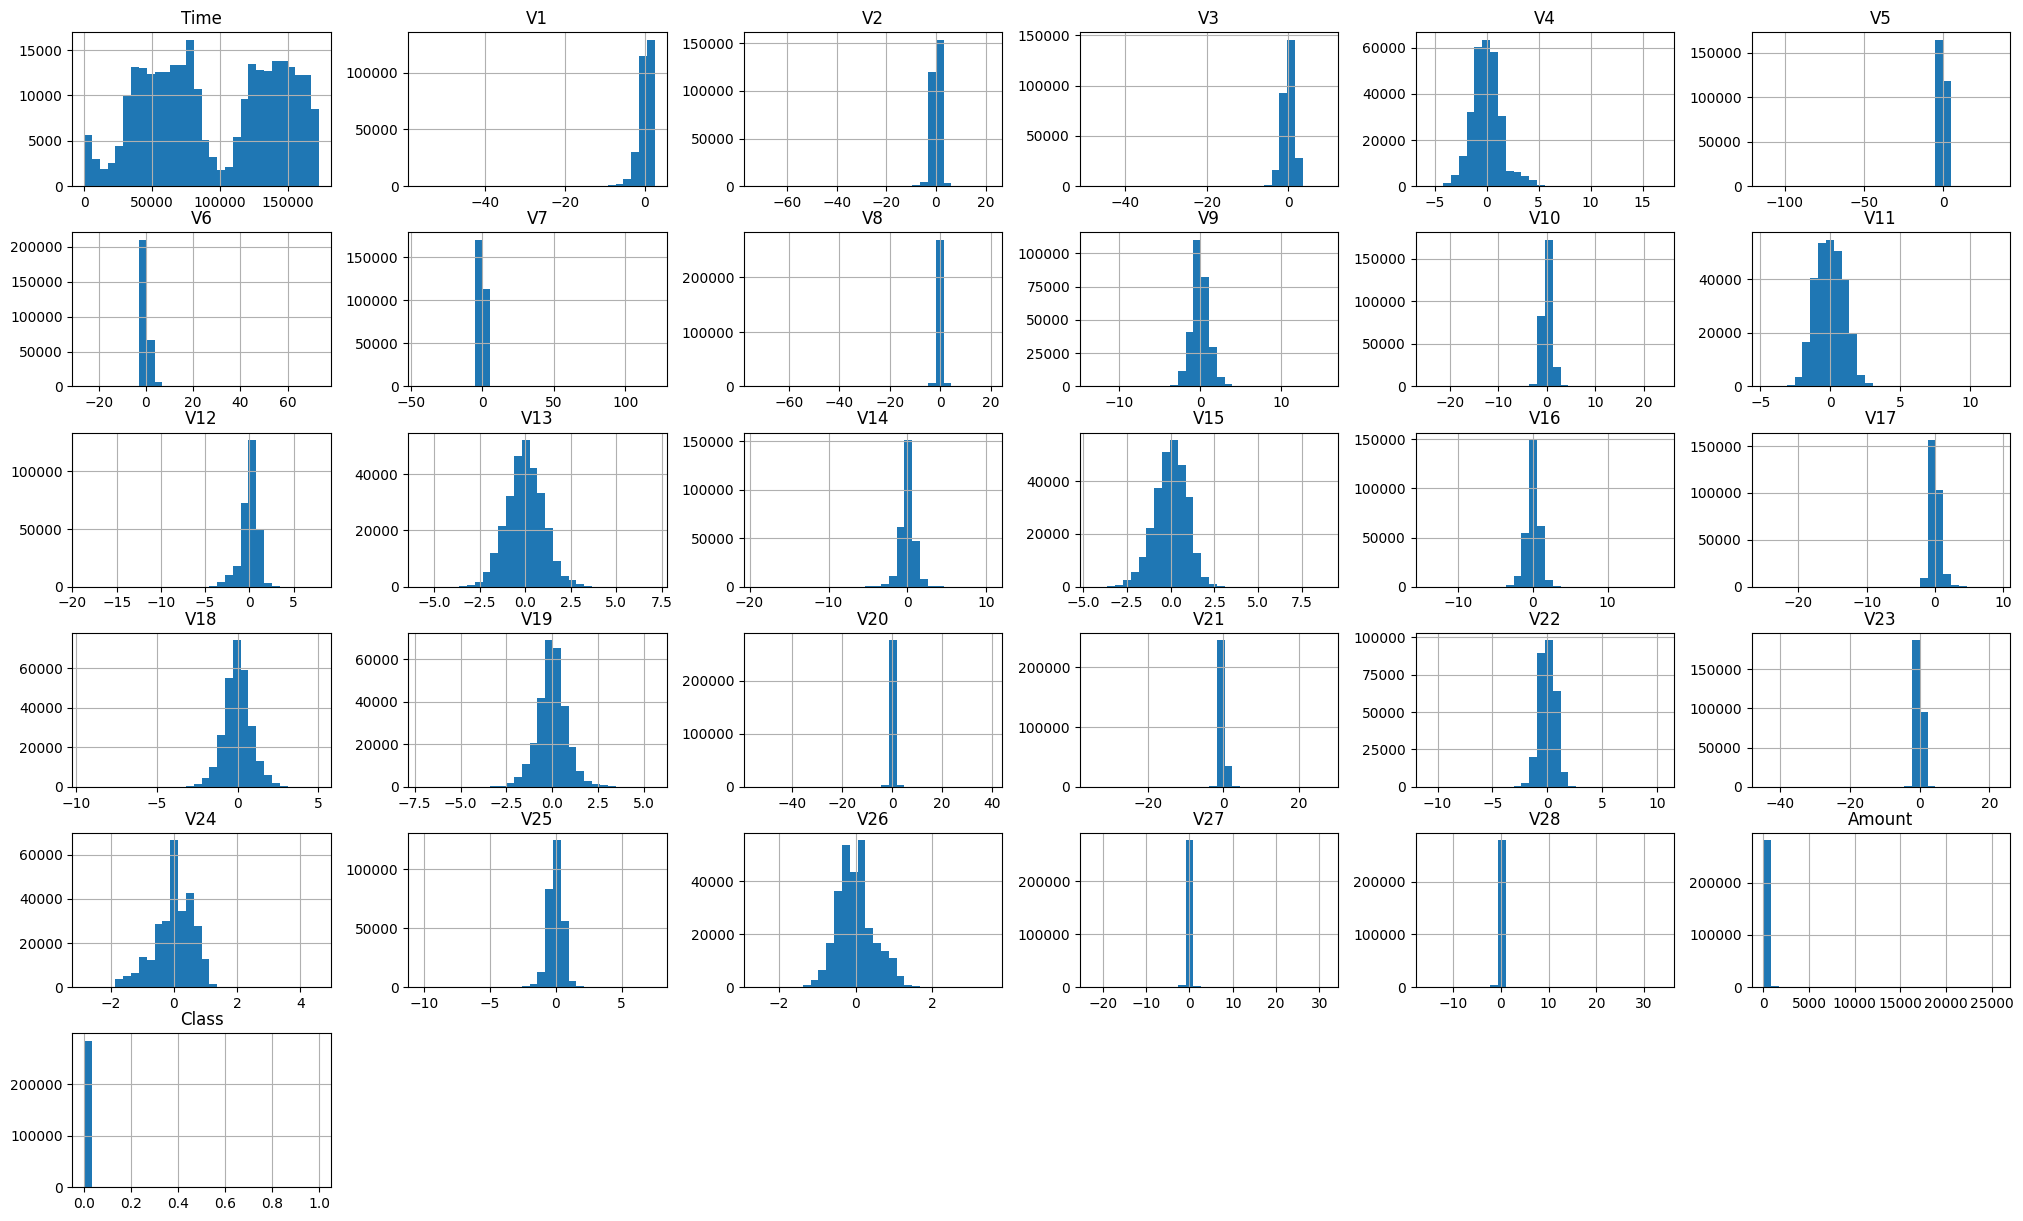

In [31]:
df.hist(bins=30,figsize=(25, 15))

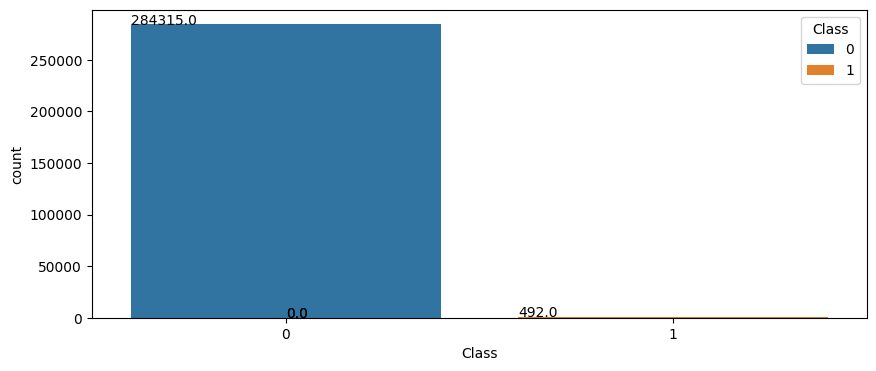

In [32]:
plt.figure(figsize = (10, 4))
ax=sns.countplot(df, x = "Class", hue="Class")
for p in ax.patches:
        ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x(), p.get_height()))

In [33]:
df.describe(include='all').round(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,...,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000,284807.00000
mean,94813.85958,0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,...,0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,88.34962,0.00173
std,47488.14595,1.95870,1.65131,1.51626,1.41587,1.38025,1.33227,1.23709,1.19435,1.09863,...,0.73452,0.72570,0.62446,0.60565,0.52128,0.48223,0.40363,0.33008,250.12011,0.04153
min,0.00000,-56.40751,-72.71573,-48.32559,-5.68317,-113.74331,-26.16051,-43.55724,-73.21672,-13.43407,...,-34.83038,-10.93314,-44.80774,-2.83663,-10.29540,-2.60455,-22.56568,-15.43008,0.00000,0.00000
25%,54201.50000,-0.92037,-0.59855,-0.89036,-0.84864,-0.69160,-0.76830,-0.55408,-0.20863,-0.64310,...,-0.22839,-0.54235,-0.16185,-0.35459,-0.31715,-0.32698,-0.07084,-0.05296,5.60000,0.00000
50%,84692.00000,0.01811,0.06549,0.17985,-0.01985,-0.05434,-0.27419,0.04010,0.02236,-0.05143,...,-0.02945,0.00678,-0.01119,0.04098,0.01659,-0.05214,0.00134,0.01124,22.00000,0.00000
75%,139320.50000,1.31564,0.80372,1.02720,0.74334,0.61193,0.39856,0.57044,0.32735,0.59714,...,0.18638,0.52855,0.14764,0.43953,0.35072,0.24095,0.09105,0.07828,77.16500,0.00000
max,172792.00000,2.45493,22.05773,9.38256,16.87534,34.80167,73.30163,120.58949,20.00721,15.59499,...,27.20284,10.50309,22.52841,4.58455,7.51959,3.51735,31.61220,33.84781,25691.16000,1.00000


<Axes: >

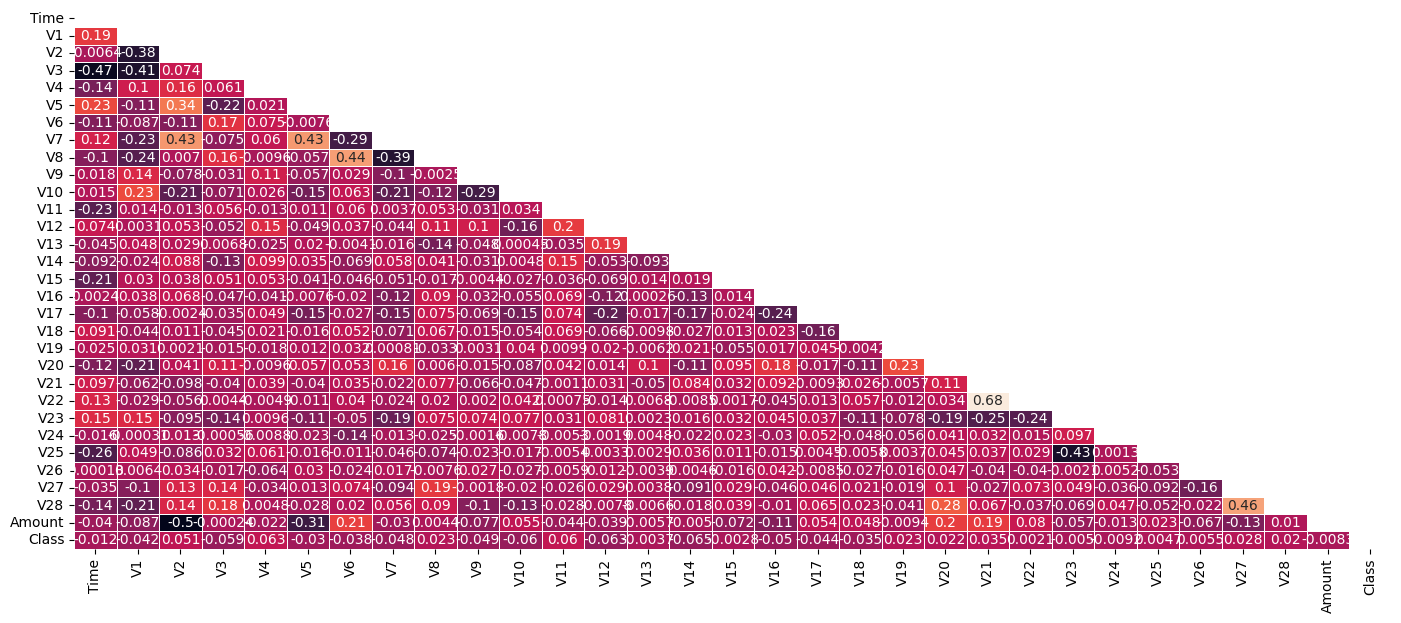

In [34]:
plt.figure(figsize = (17,7))
df_corr = df.corr(method='spearman', numeric_only = True)
sns.heatmap(df_corr, annot=True, linewidth=.5, cbar = False, mask=np.triu(np.ones_like(df_corr, dtype=bool)))

In [35]:
df_new = df.copy()
df_new = df_new.drop(['V15','V16','V17','V18','V19','V20','V21','V22','V23','V24','V25','V26','V27','V28'], axis=1)

In [36]:
df_new.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,69.99,0


In [37]:
df_train, df_test= train_test_split(df_new, train_size=0.8, random_state=42, stratify=df_new.Class)

In [38]:
#Scaling
rs = RobustScaler()
df_sc_train= rs.set_output(transform='pandas').fit_transform(df_train)
df_sc_test= rs.set_output(transform='pandas').transform(df_test)

In [39]:
# df_sc_train.Class.value_counts()

In [40]:
X_sc_train = df_sc_train.drop('Class', axis=1)
y_train = df_sc_train['Class']
X_sc_test = df_sc_test.drop('Class', axis=1)
y_test = df_sc_test['Class']

ROC_curve, Precision-Recall Curve function

In [41]:
def plot_roc(fpr, tpr):
    plt.plot(fpr, tpr, label='ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend()
    plt.show()

In [42]:
def plot_prc(precision, recall):
    plt.plot(precision, recall, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

ML

Baseline (RobustScaler)

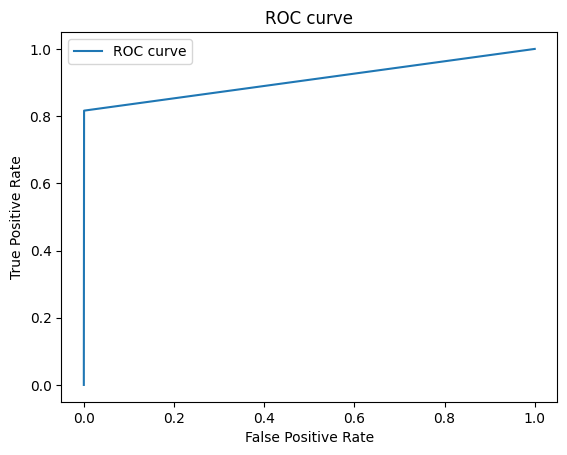

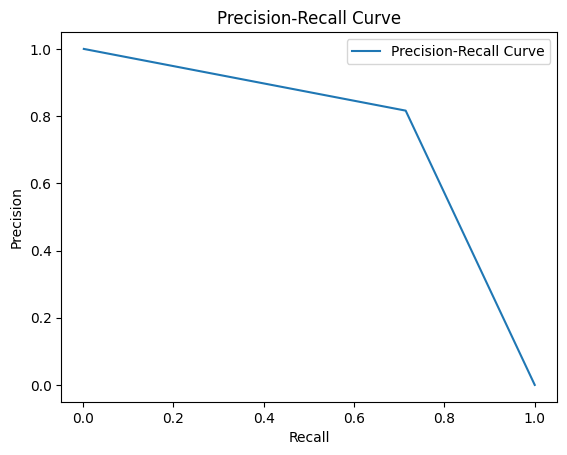

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.71      0.82      0.76        98

    accuracy                           1.00     56962
   macro avg       0.86      0.91      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC_AUC: 0.9078818922053908
AUC: 0.7654641225192019
Log_loss: 0.03163833203637285


In [43]:
dt = DecisionTreeClassifier()
dt_model = dt.fit(X_sc_train, y_train)
fpr, tpr, _ = roc_curve(y_test, dt_model.predict_proba(X_sc_test)[:, 1])
precision, recall, thresholds = precision_recall_curve(y_test, dt_model.predict_proba(X_sc_test)[:, 1])
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, dt_model.predict(X_sc_test), target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, dt_model.predict_proba(X_sc_test)[:, 1]))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,dt_model.predict_proba(X_sc_test)))

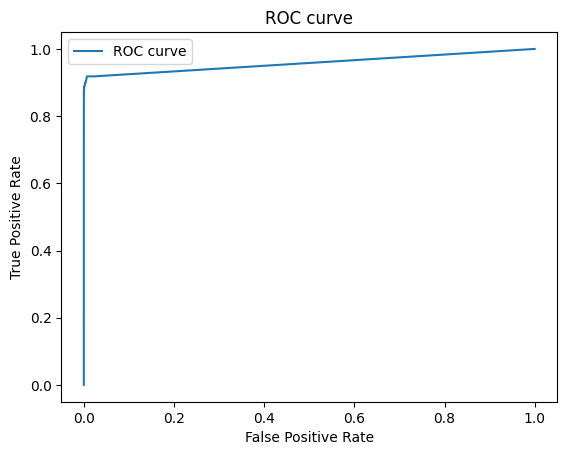

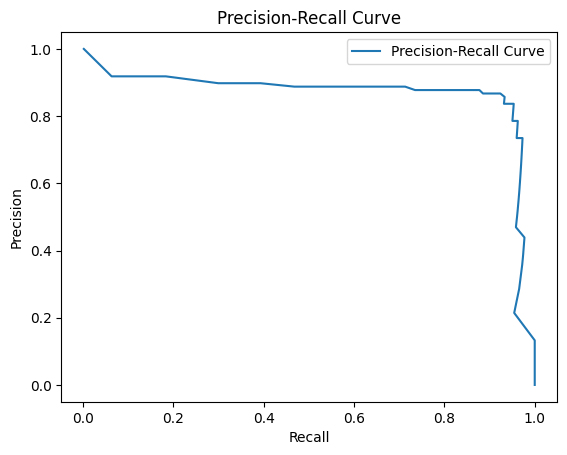

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC_AUC: 0.9580644617160313
AUC: 0.870365577245175
Log_loss: 0.006256068393348941


In [44]:
rf = RandomForestClassifier()
rf_model = rf.fit(X_sc_train, y_train)
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_sc_test)[:, 1])
precision, recall, thresholds = precision_recall_curve(y_test, rf_model.predict_proba(X_sc_test)[:, 1])
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, rf_model.predict(X_sc_test), target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_sc_test)[:, 1]))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,rf_model.predict_proba(X_sc_test)))

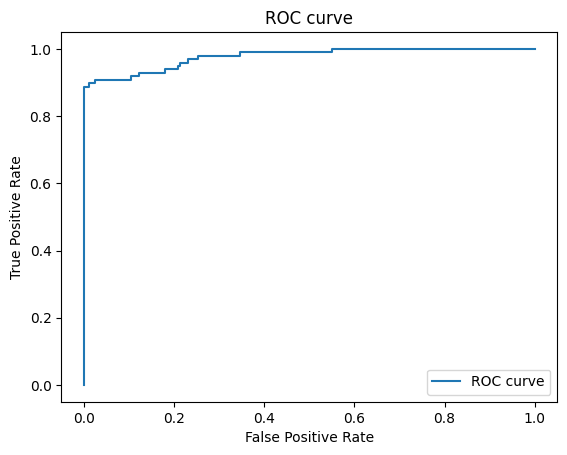

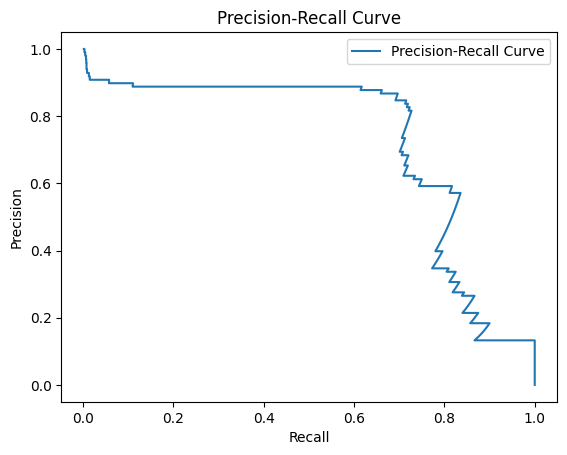

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.73      0.62      0.67        98

    accuracy                           1.00     56962
   macro avg       0.86      0.81      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC_AUC: 0.9768346315735073
AUC: 0.7250376887857416
Log_loss: 0.00458671926444271


In [45]:
lg = LogisticRegression(max_iter=400, penalty="l2", warm_start=False)
lg_model = lg.fit(X_sc_train, y_train)
fpr, tpr, _ = roc_curve(y_test, lg_model.predict_proba(X_sc_test)[:, 1])
precision, recall, thresholds = precision_recall_curve(y_test, lg_model.predict_proba(X_sc_test)[:, 1])
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, lg_model.predict(X_sc_test), target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, lg_model.predict_proba(X_sc_test)[:, 1]))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,lg_model.predict_proba(X_sc_test)))

Deep learning

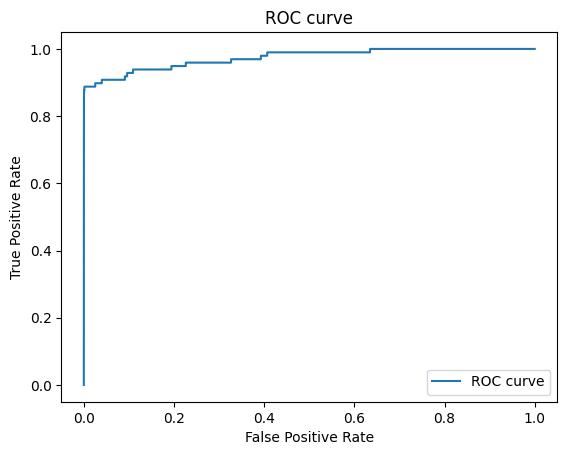

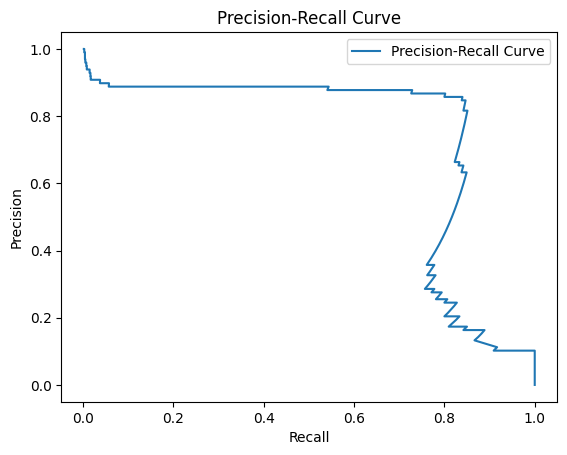

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC_AUC: 0.973904259931322
AUC: 0.7454655706266439
Log_loss: 0.00360134449345814


In [46]:
# PyTorch RNN Model
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(Net, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, h_n = self.rnn(x, h0)
        out = out[:, -1, :]  # Take last output
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=1)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # if (epoch + 1) % 50 == 0:
        #     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=1)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()


# Hyperparameters
input_size = 16
hidden_size = 2
num_layers = 3
num_classes = 2
local_epochs = 1200
device = torch.device('cpu')

# Initialize model
rnn_model = Net(input_size, hidden_size, num_layers, num_classes)
# print(f"RNN Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(rnn_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(rnn_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))


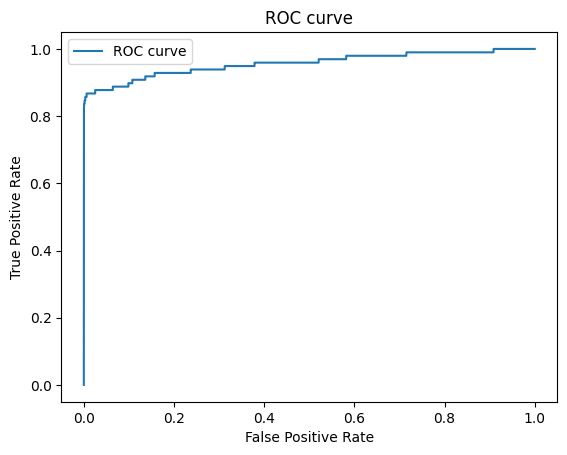

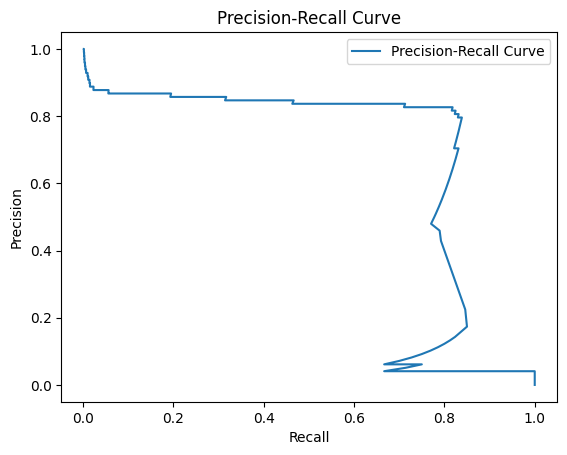

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC_AUC: 0.9564436055091704
AUC: 0.6944749470341376
Log_loss: 0.0034774193408251843


In [47]:
# PyTorch GRU Model
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(Net, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, h_n = self.gru(x, h0)
        out = out[:, -1, :]  # Take last output
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=1)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # if (epoch + 1) % 50 == 0:
        #     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=1)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()


# Hyperparameters
input_size = 16
hidden_size = 2
num_layers = 3
num_classes = 2
local_epochs = 1200
device = torch.device('cpu')

# Initialize model
gru_model = Net(input_size, hidden_size, num_layers, num_classes)
# print(f"GRU Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(gru_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(gru_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))


Epoch [50/1200], Loss: 0.0799
Epoch [100/1200], Loss: 0.0286
Epoch [150/1200], Loss: 0.0198
Epoch [200/1200], Loss: 0.0161
Epoch [250/1200], Loss: 0.0140
Epoch [300/1200], Loss: 0.0124
Epoch [350/1200], Loss: 0.0108
Epoch [400/1200], Loss: 0.0089
Epoch [450/1200], Loss: 0.0071
Epoch [500/1200], Loss: 0.0059
Epoch [550/1200], Loss: 0.0052
Epoch [600/1200], Loss: 0.0047
Epoch [650/1200], Loss: 0.0043
Epoch [700/1200], Loss: 0.0040
Epoch [750/1200], Loss: 0.0038
Epoch [800/1200], Loss: 0.0036
Epoch [850/1200], Loss: 0.0035
Epoch [900/1200], Loss: 0.0033
Epoch [950/1200], Loss: 0.0032
Epoch [1000/1200], Loss: 0.0032
Epoch [1050/1200], Loss: 0.0031
Epoch [1100/1200], Loss: 0.0030
Epoch [1150/1200], Loss: 0.0030
Epoch [1200/1200], Loss: 0.0029


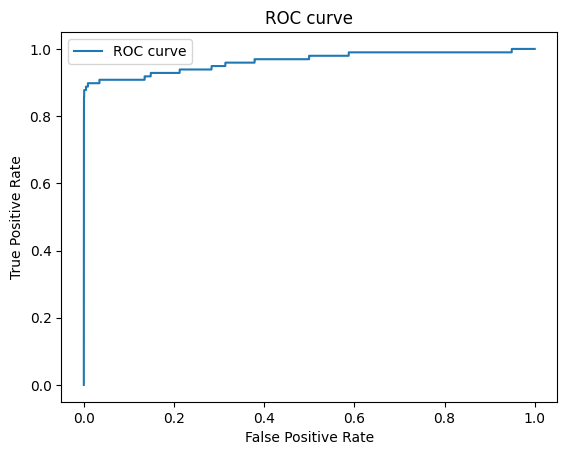

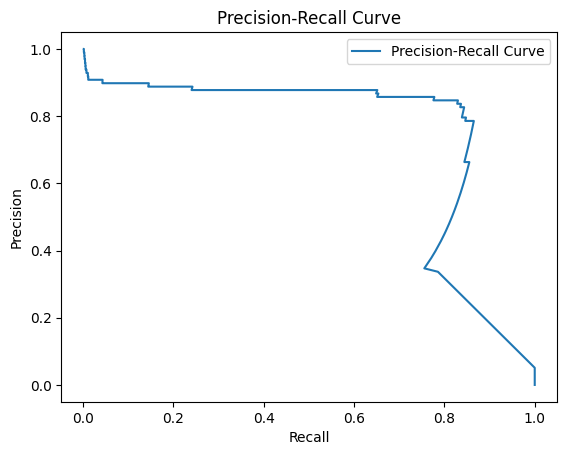

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC_AUC: 0.9635698099583108
AUC: 0.7537180230386772
Log_loss: 0.0032441493052202445


In [48]:
# PyTorch LSTM Model
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(Net, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x,(h0,c0))   # out = batch_size, seq_legnth, hidden_size
        out = out [:, -1, :]
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=1)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=1)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()


# Hyperparameters
input_size = 16
hidden_size = 2
num_layers = 3
num_classes = 2
local_epochs = 1200
device = torch.device('cpu')

# Initialize model
lstm_model = Net(input_size, hidden_size, num_layers, num_classes)

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(lstm_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(lstm_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))


In [49]:
# PyTorch Muti-head attention Model
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)
    if mask is not None:
        scaled += mask
    attention = F.softmax(scaled, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

class MultiheadAttention(nn.Module):

    def __init__(self, input_dim, dim_model, num_heads):
        super().__init__()
        self.input_dim = input_dim
        self.dim_model = dim_model
        self.num_heads = num_heads
        self.head_dim = dim_model // num_heads
        
        self.qkv_layer = nn.Linear(input_dim , 3 * dim_model)
        self.linear_layer = nn.Linear(dim_model, dim_model)
    
    def forward(self, x, mask):
        batch_size, sequence_length, input_dim = x.size()
        qkv = self.qkv_layer(x)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        qkv = qkv.permute(0, 2, 1, 3)   # change position to [batch_size, num_heads, sequence_length, 3*head_dim]
        q, k, v = qkv.chunk(3, dim=-1)
        values, attention = scaled_dot_product(q, k, v, mask)
        values = values.reshape(batch_size, sequence_length, self.num_heads * self.head_dim)
        out = self.linear_layer(values)
        return out, values

class Net(nn.Module):
    def __init__(self, input_dim, dim_model, num_classes, num_heads):
        super(Net, self).__init__()
        self.multihead_attention = MultiheadAttention(input_dim=input_dim, dim_model=dim_model, num_heads=num_heads)
        self.layer_norm = nn.LayerNorm(dim_model)
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(dim_model, num_classes)
    
    def forward(self, x, mask=None):
        # Apply Multihead Attention
        attn_output, _ = self.multihead_attention(x, mask)
        
        # Add normalization and dropout for better training
        attn_output = self.layer_norm(attn_output)
        attn_output = self.dropout(attn_output)
        
        # Use global average pooling instead of just last position, this considers all feature relationships learned by attention
        out = torch.mean(attn_output, dim=1)  # [batch_size, dim_model]
        out = self.fc(out)
        return out

def train_model(net, X_train, y_train, epochs, device):
    """Train the model"""
    net.to(device)
    criterion = torch.nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    net.train()
    
    X_train_tensor = torch.from_numpy(np.expand_dims(X_train, axis=2)).to(device)
    y_train_tensor = torch.from_numpy(y_train).long().to(device)
    
    running_loss = 0.0
    for epoch in range(epochs):
        outputs = net(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
    
    return running_loss / epochs

def test_model(net, X_test, y_test, device):
    """Test the model"""
    net.to(device)
    net.eval()
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(np.expand_dims(X_test, axis=2)).to(device)
        y_test_tensor = torch.from_numpy(y_test).long().to(device)
        
        outputs = net(X_test_tensor)
        loss = criterion(outputs, y_test_tensor).item()
        
        probs = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        predictions = torch.max(outputs.data, 1)[1]
        correct = (predictions == y_test_tensor).sum().item()
        accuracy = correct / len(y_test)
    
    return loss, accuracy, probs, predictions.cpu().numpy()

# Hyperparameters
input_dim = 1
dim_model = 32
num_classes = 2
num_heads = 4
local_epochs = 500
device = torch.device('cpu')

# Initialize model
muti_head_model = Net(input_dim, dim_model, num_classes, num_heads)
# print(f"LSTM Model initialized - Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}, Classes: {num_classes}")
# print("Model ready for training with X_sc_train, y_train, X_sc_test, y_test")

X_sc_train_temp = X_sc_train.astype('float32').values
y_train_temp = y_train.astype('float32').values
X_sc_test_temp = X_sc_test.astype('float32').values
y_test_temp = y_test.astype('float32').values

avg_loss = train_model(muti_head_model, X_sc_train_temp, y_train_temp, local_epochs, device)
loss, accuracy, X_preds, y_labels = test_model(muti_head_model, X_sc_test_temp, y_test_temp, device)
# print(f"Training Loss: {avg_loss:.4f}, Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Convert probabilities to binary class predictions
y_pred = [1 if p >= 0.5 else 0 for p in X_preds]

fpr, tpr, _ = roc_curve(y_test, X_preds)
precision, recall, thresholds = precision_recall_curve(y_test, X_preds)
plot_roc(fpr, tpr)
plot_prc(precision, recall)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print("ROC_AUC:", roc_auc_score(y_test, X_preds))
print("AUC:", auc(recall, precision))
print("Log_loss:", log_loss(y_test,X_preds))


Epoch [50/500], Loss: 0.0070


KeyboardInterrupt: 

Export dataset

In [ ]:
df_1 = pd.concat([df_sc_train, df_sc_test], axis=0, join='inner')
df_1.to_csv('df_1.csv')
df_1

Export dataset test and train

In [ ]:
df_sc_train.to_csv('df_train_1.csv')
df_sc_test.to_csv('df_test_1.csv')

In [ ]:
# df_train = pd.read_csv('df_train_1.csv')
# df_test = pd.read_csv('df_test_1.csv')
# df_train.drop("Unnamed: 0", axis=1, inplace=True)
# df_test.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
# X_train = df_train.drop('Class', axis=1)
# y_train = df_train['Class']
# X_test = df_test.drop('Class', axis=1)
# y_test = df_test['Class']

In [ ]:
# df_new = df_train.sample(frac = 0.25)
# # df_new.drop("Unnamed: 0", axis=1, inplace=True)
# X = df_new.drop('Class', axis=1).values
# y = df_new['Class'].values
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ,stratify=y)

In [ ]:
# lg = LogisticRegression(max_iter=300, penalty="l2", warm_start=False)
# lg_model = lg.fit(X_train, y_train)
# fpr, tpr, _ = roc_curve(y_test, lg_model.predict_proba(X_test)[:, 1])
# precision, recall, thresholds = precision_recall_curve(y_test, lg_model.predict_proba(X_test)[:, 1])
# print(classification_report(y_test, lg_model.predict(X_test), target_names=['Not Fraud', 'Fraud']))
# print("ROC_AUC:", roc_auc_score(y_test, lg_model.predict_proba(X_test)[:, 1]))
# print("AUC:", auc(recall, precision))
# print("Log_loss:", log_loss(y_test,lg_model.predict_proba(X_test)))